In [11]:
from typing import List, Optional
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

import os
import json
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END

c:\Users\fkrii\OneDrive\Desktop\Langchain_Langgraph\Langchain\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
load_dotenv(".env")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3-32b")

##### Creating the first agent - ps decomposition

In [13]:
class SubProblem(BaseModel):
    title: str = Field(
        description="Short technical title of the subproblem"
    )
    description: str = Field(
        description="What this subproblem means technically"
    )
    why_it_matters: str = Field(
        description="Why this subproblem is important for solving the full problem statement"
    )
    research_angle: str = Field(
        description="What kind of research papers would help solve this subproblem"
    )
    search_keywords: List[str] = Field(
        description="Important technical keywords useful for search"
    )
    search_queries: List[str] = Field(
        description="Academic search queries useful for arXiv, Semantic Scholar, Papers with Code, or Google Scholar"
    )


class ProblemDecomposition(BaseModel):
    main_objective: str = Field(
        description="Main goal of the problem statement"
    )
    problem_type: str = Field(
        description="Broad technical category such as RAG, NLP, CV, cybersecurity, optimization, recommender systems, etc."
    )
    required_capabilities: List[str] = Field(
        description="Main capabilities the final system must have"
    )
    constraints: List[str] = Field(
        description="Explicit or implied constraints from the problem statement"
    )
    assumptions_or_ambiguities: List[str] = Field(
        description="Important unclear parts or assumptions that may need clarification"
    )
    subproblems: List[SubProblem] = Field(
        description="List of useful research-searchable technical subproblems"
    )

In [14]:
#added critique for the critique agent
class ResearchState(TypedDict):
    problem_statement: str
    decomposed_problem_statement: Optional[ProblemDecomposition]
    
    decomposition_critique: Optional[dict]

In [15]:
decomposition_model = model.with_structured_output(ProblemDecomposition)

system_prompt = """
You are an expert AI research assistant helping a team solve technical competition problem statements.

Your task is to decompose the given problem statement into useful technical subproblems.

Rules:
1. Do not solve the problem directly.
2. Break the problem into research-searchable technical subproblems.
3. Each subproblem should be specific enough to search for useful research papers.
4. Avoid vague subproblems like "build model", "make frontend", or "collect data".
5. Prefer research-oriented decomposition when relevant.
6. Mention constraints and ambiguities honestly.
7. The output should be useful for a later paper retrieval agent.
8. For each subproblem, generate 2 to 4 strong academic search queries.
9. Search queries should be suitable for arXiv, Semantic Scholar, Papers with Code, or Google Scholar.
10. Do not add random technologies unless they are supported by the problem statement.
"""

In [16]:
def decompose_problem(problem_statement: str) -> ProblemDecomposition:   #this is not a node functionality, im defining node to breakdown the ps
    problem_statement = problem_statement.strip()
    
    if not problem_statement:
        raise ValueError("Problem statement is empty")
    
    messages = [
        ("system", system_prompt),
        ("user", f"Problem Statement:\n{problem_statement}")
    ]
    
    decomposition = decomposition_model.invoke(messages)
    return decomposition

In [17]:
def decompose_problem_node(state: ResearchState) -> ResearchState:   #decomposition node
    ps = state["problem_statement"]
    
    decomposition = decompose_problem(ps)
    
    return {
        "decomposed_problem_statement": decomposition
    }

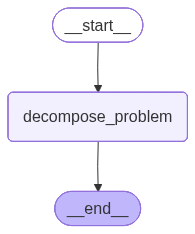

In [18]:
graph_builder = StateGraph(ResearchState)

graph_builder.add_node("decompose_problem", decompose_problem_node)

graph_builder.add_edge(START, "decompose_problem")
graph_builder.add_edge("decompose_problem", END)

graph = graph_builder.compile()
graph

In [19]:
#testing and pretty print
test_ps = """
Build an AI system that takes competition problem statements, breaks them into technical components,
searches research papers for each component, ranks papers by usefulness, and generates an implementation plan.
"""

initial_state = {
    "problem_statement": test_ps,
    "decomposed_problem_statement": None,
    "decomposition_critique": None
}

result = graph.invoke(initial_state)

decomp = result["decomposed_problem_statement"]

print("MAIN OBJECTIVE:")
print(decomp.main_objective)

print("\nPROBLEM TYPE:")
print(decomp.problem_type)

print("\nREQUIRED CAPABILITIES:")
for cap in decomp.required_capabilities:
    print("-", cap)

print("\nCONSTRAINTS:")
for constraint in decomp.constraints:
    print("-", constraint)

print("\nASSUMPTIONS / AMBIGUITIES:")
for item in decomp.assumptions_or_ambiguities:
    print("-", item)

print("\nSUBPROBLEMS:")
for i, sp in enumerate(decomp.subproblems, start=1):
    print(f"\n{i}. {sp.title}")
    print("Description:", sp.description)
    print("Why it matters:", sp.why_it_matters)
    print("Research angle:", sp.research_angle)
    
    print("Keywords:")
    for kw in sp.search_keywords:
        print(" -", kw)
    
    print("Search queries:")
    for q in sp.search_queries:
        print(" -", q)

MAIN OBJECTIVE:
Build an AI system that converts competition problem statements into technical subproblems, retrieves relevant research papers, ranks them by usefulness, and generates implementation plans.

PROBLEM TYPE:
Natural Language Processing, Information Retrieval, Knowledge Synthesis

REQUIRED CAPABILITIES:
- Semantic decomposition of problem statements
- Automated academic paper search
- Research relevance ranking
- Technical plan generation

CONSTRAINTS:
- Must handle ambiguous or complex problem formulations
- Requires domain-agnostic decomposition techniques
- Paper ranking must balance novelty and practicality
- Implementation plans need actionable technical steps

ASSUMPTIONS / AMBIGUITIES:
- Assumes access to academic databases with APIs
- Unclear if domain-specific knowledge is needed
- Ranking criteria (citations vs. relevance) not specified
- Implementation plan format requirements undefined

SUBPROBLEMS:

1. Problem Statement Decomposition
Description: Extract techni

##### creating second agent/first critique agent to critique the ps decomposition

creating a three stage critique  
- first stage classifies individual subproblems as good/bad and assigns scores, etc instead of critiquing the entire decomposition as one
- second stage works on revising the bad subproblem divisions
- third state performs revision again

In [20]:
#critique schemas
class SingleSubProblemCritique(BaseModel):
    subproblem_index: int = Field(
        description="Index of the subproblem being critiqued, starting from 0"
    )
    subproblem_title: str = Field(
        description="Title of the subproblem being critiqued"
    )
    is_good: bool = Field(
        description="Whether this subproblem is good enough to keep as it is"
    )
    score: float = Field(
        ge=0.0,
        le=1.0,
        description="Quality score from 0 to 1"
    )
    issues: List[str] = Field(
        description="Problems with this subproblem"
    )
    missing_aspects: List[str] = Field(
        description="Important things missing from this subproblem"
    )
    improvement_suggestions: List[str] = Field(
        description="How this subproblem should be improved"
    )


class DecompositionCritiqueReport(BaseModel):
    overall_score: float = Field(
        ge=0.0,
        le=1.0,
        description="Overall quality score of the decomposition"
    )
    subproblem_critiques: List[SingleSubProblemCritique] = Field(
        description="Critique for each subproblem"
    )
    global_missing_aspects: List[str] = Field(
        description="Important parts of the original PS missing from the entire decomposition"
    )
    should_revise: bool = Field(
        description="Whether any subproblem should be revised"
    )

In [21]:
#revision schemas
class RevisedSubProblem(BaseModel):
    original_subproblem_index: int = Field(
        description="Index of the original bad subproblem that this revised version replaces"
    )
    revised_subproblem: SubProblem = Field(
        description="Improved version of the bad subproblem"
    )
    reason_for_revision: str = Field(
        description="Why this revised version is better"
    )


class BadSubproblemRevisionReport(BaseModel):
    revised_subproblems: List[RevisedSubProblem] = Field(
        description="Only the revised versions of bad subproblems"
    )

In [22]:
#updating the ResearchState class(this is the one thats carrying the data thru the graph)
class ResearchState(TypedDict):
    problem_statement: str

    decomposed_problem_statement: Optional[ProblemDecomposition]
    decomposition_critique: Optional[DecompositionCritiqueReport]

    refined_decomposed_problem_statement: Optional[ProblemDecomposition]
    refined_decomposition_critique: Optional[DecompositionCritiqueReport]

    revision_count: int

**stage 1 critique model**

In [23]:
subproblem_critique_model = model.with_structured_output(DecompositionCritiqueReport)

subproblem_critique_prompt = """
You are a strict critique agent for technical problem decomposition.

You will be given:
1. The original problem statement
2. A decomposition containing multiple subproblems

Your job:
- Critique EACH subproblem individually.
- Decide whether each subproblem is good enough for research paper search.
- A good subproblem should be specific, technical, research-searchable, and relevant to the PS.
- A bad subproblem is vague, too broad, missing key details, unsupported by the PS, or not useful for paper search.

Scoring guide:
0.90 - 1.00: Excellent
0.75 - 0.89: Good, can keep unchanged
0.60 - 0.74: Usable but should be improved
Below 0.60: Bad, should be revised

Rules:
- Mark is_good=True only if score >= 0.75.
- Be strict but practical.
- Do not ask for perfection.
- Mention global missing aspects if the whole decomposition misses something important from the PS.
"""

In [24]:
def critique_each_subproblem(
    problem_statement: str,
    decomposition: ProblemDecomposition
) -> DecompositionCritiqueReport:

    messages = [
        ("system", subproblem_critique_prompt),
        (
            "user",
            f"""
Original Problem Statement:
{problem_statement}

Decomposition:
{decomposition.model_dump_json(indent=2)}

Critique every subproblem one by one.
"""
        )
    ]

    return subproblem_critique_model.invoke(messages)

In [25]:
def critique_each_subproblem(
    problem_statement: str,
    decomposition: ProblemDecomposition
) -> DecompositionCritiqueReport:

    messages = [
        ("system", subproblem_critique_prompt),
        (
            "user",
            f"""
Original Problem Statement:
{problem_statement}

Decomposition:
{decomposition.model_dump_json(indent=2)}

Critique every subproblem one by one.
"""
        )
    ]

    return subproblem_critique_model.invoke(messages)

In [26]:
def critique_original_decomposition_node(state: ResearchState) -> ResearchState:
    decomposition = state["decomposed_problem_statement"]

    if decomposition is None:
        raise ValueError("No decomposed_problem_statement found in state")

    critique = critique_each_subproblem(
        problem_statement=state["problem_statement"],
        decomposition=decomposition
    )

    return {
        "decomposition_critique": critique
    }

**stage 2 revision model**

In [27]:
bad_subproblem_revision_model = model.with_structured_output(BadSubproblemRevisionReport)

In [28]:
bad_subproblem_revision_prompt = """
You are a decomposition refinement agent.

You will be given:
1. The original problem statement
2. The original decomposition
3. Critiques for bad subproblems

Your job:
- Revise ONLY the bad subproblems.
- Bad subproblems are those with is_good=False or score < 0.75.
- Do not change good subproblems.
- Do not add random technologies unsupported by the PS.
- Make each revised subproblem specific, technical, and useful for research paper search.
- Each revised subproblem must include useful search keywords and academic search queries.
"""

In [29]:
def get_bad_critiques(
    critique: DecompositionCritiqueReport
) -> List[SingleSubProblemCritique]:

    bad_critiques = []

    for c in critique.subproblem_critiques:
        if (not c.is_good) or c.score < 0.75:
            bad_critiques.append(c)

    return bad_critiques

In [30]:
def revise_bad_subproblems_once(
    problem_statement: str,
    decomposition: ProblemDecomposition,
    critique: DecompositionCritiqueReport
) -> tuple[ProblemDecomposition, int]:

    bad_critiques = get_bad_critiques(critique)

    if len(bad_critiques) == 0:
        return decomposition, 0

    messages = [
        ("system", bad_subproblem_revision_prompt),
        (
            "user",
            f"""
Original Problem Statement:
{problem_statement}

Original Decomposition:
{decomposition.model_dump_json(indent=2)}

Bad Subproblem Critiques:
{json.dumps([c.model_dump() for c in bad_critiques], indent=2)}

Revise only these bad subproblems.
"""
        )
    ]

    revision_report = bad_subproblem_revision_model.invoke(messages)

    decomposition_dict = decomposition.model_dump()

    bad_indexes = {c.subproblem_index for c in bad_critiques}
    revised_indexes = set()

    for item in revision_report.revised_subproblems:
        idx = item.original_subproblem_index

        if idx < 0 or idx >= len(decomposition_dict["subproblems"]):
            raise ValueError(f"Invalid subproblem index returned by revision agent: {idx}")

        decomposition_dict["subproblems"][idx] = item.revised_subproblem.model_dump()
        revised_indexes.add(idx)

    missing_revisions = bad_indexes - revised_indexes

    if missing_revisions:
        print("Warning: These bad subproblems were not revised:", missing_revisions)

    refined_decomposition = ProblemDecomposition.model_validate(decomposition_dict)

    return refined_decomposition, 1

stage 2 node

In [31]:
def revise_bad_subproblems_node(state: ResearchState) -> ResearchState:
    decomposition = state["decomposed_problem_statement"]
    critique = state["decomposition_critique"]

    if decomposition is None:
        raise ValueError("No decomposed_problem_statement found in state")

    if critique is None:
        raise ValueError("No decomposition_critique found in state")

    refined_decomposition, revision_count = revise_bad_subproblems_once(
        problem_statement=state["problem_statement"],
        decomposition=decomposition,
        critique=critique
    )

    return {
        "refined_decomposed_problem_statement": refined_decomposition,
        "revision_count": revision_count
    }

**stage 3 re-critiquing**

stage 3 node, it uses the classes and functions defined for critiquing in stage 2

In [32]:
def critique_refined_decomposition_node(state: ResearchState) -> ResearchState:
    refined_decomposition = state["refined_decomposed_problem_statement"]

    if refined_decomposition is None:
        raise ValueError("No refined_decomposed_problem_statement found in state")

    refined_critique = critique_each_subproblem(
        problem_statement=state["problem_statement"],
        decomposition=refined_decomposition
    )

    return {
        "refined_decomposition_critique": refined_critique
    }

graph including this critiquing agent

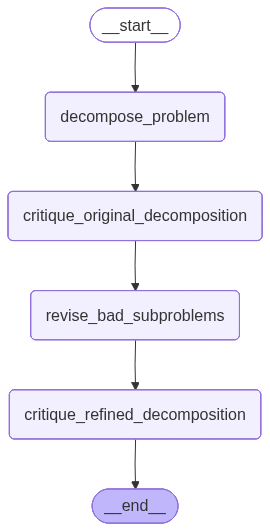

In [33]:
graph_builder = StateGraph(ResearchState)

graph_builder.add_node("decompose_problem", decompose_problem_node)
graph_builder.add_node("critique_original_decomposition", critique_original_decomposition_node)
graph_builder.add_node("revise_bad_subproblems", revise_bad_subproblems_node)
graph_builder.add_node("critique_refined_decomposition", critique_refined_decomposition_node)

graph_builder.add_edge(START, "decompose_problem")
graph_builder.add_edge("decompose_problem", "critique_original_decomposition")
graph_builder.add_edge("critique_original_decomposition", "revise_bad_subproblems")
graph_builder.add_edge("revise_bad_subproblems", "critique_refined_decomposition")
graph_builder.add_edge("critique_refined_decomposition", END)

graph = graph_builder.compile()
graph

testing first critique agent

In [34]:
test_ps = """
Build an AI system that takes competition problem statements, breaks them into technical components,
searches research papers for each component, ranks papers by usefulness, and generates an implementation plan.
"""

initial_state = {
    "problem_statement": test_ps,

    "decomposed_problem_statement": None,
    "decomposition_critique": None,

    "refined_decomposed_problem_statement": None,
    "refined_decomposition_critique": None,

    "revision_count": 0
}

result = graph.invoke(initial_state)

KeyboardInterrupt: 

In [ ]:
#original critique
critique = result["decomposition_critique"]

print("ORIGINAL DECOMPOSITION CRITIQUE")
print("Overall score:", critique.overall_score)
print("Should revise:", critique.should_revise)

for c in critique.subproblem_critiques:
    print("\n" + "=" * 80)
    print("Index:", c.subproblem_index)
    print("Title:", c.subproblem_title)
    print("Is good:", c.is_good)
    print("Score:", c.score)

    print("\nIssues:")
    for issue in c.issues:
        print("-", issue)

    print("\nMissing aspects:")
    for item in c.missing_aspects:
        print("-", item)

    print("\nSuggestions:")
    for suggestion in c.improvement_suggestions:
        print("-", suggestion)

ORIGINAL DECOMPOSITION CRITIQUE
Overall score: 0.82
Should revise: True

Index: 0
Title: Technical Component Decomposition
Is good: True
Score: 0.85

Issues:
- Slightly vague on how 'structured technical subproblems' will be represented

Missing aspects:
- Need to address domain adaptation for different technical domains

Suggestions:
- Add specifics about output format for structured subproblems
- Include domain adaptation considerations

Index: 1
Title: Academic Paper Retrieval System
Is good: True
Score: 0.82

Issues:
- Could be more specific about which academic databases will be used

Missing aspects:
- Need to address semantic understanding of technical components for effective mapping

Suggestions:
- Specify target repositories (arXiv, ACL, etc.)
- Add mention of semantic similarity techniques

Index: 2
Title: Paper Relevance Ranking
Is good: True
Score: 0.84

Issues:
- Definition of 'utility' remains ambiguous

Missing aspects:
- Need to address multi-step implementation depend

In [ ]:
#refined critique
refined_critique = result["refined_decomposition_critique"]

print("REFINED DECOMPOSITION CRITIQUE")
print("Revision count:", result["revision_count"])
print("Overall score:", refined_critique.overall_score)
print("Should revise:", refined_critique.should_revise)

for c in refined_critique.subproblem_critiques:
    print("\n" + "=" * 80)
    print("Index:", c.subproblem_index)
    print("Title:", c.subproblem_title)
    print("Is good:", c.is_good)
    print("Score:", c.score)

    print("\nIssues:")
    for issue in c.issues:
        print("-", issue)

REFINED DECOMPOSITION CRITIQUE
Revision count: 0
Overall score: 0.82
Should revise: True

Index: 0
Title: Technical Component Decomposition
Is good: True
Score: 0.85

Issues:
- Lacks explicit mention of domain adaptation requirements
- Doesn't specify handling of nested/multi-step problems

Index: 1
Title: Academic Paper Retrieval System
Is good: True
Score: 0.88

Issues:
- Could better specify database coverage requirements
- Missing information about query formulation strategies

Index: 2
Title: Paper Relevance Ranking
Is good: False
Score: 0.78

Issues:
- Usefulness metrics remain too ambiguous
- No mention of contextual relevance factors

Index: 3
Title: Implementation Plan Generation
Is good: True
Score: 0.82

Issues:
- Lacks technical details about code synthesis
- Doesn't address gap between research and implementation


In [ ]:
#comparing original and refined
original = result["decomposed_problem_statement"]
refined = result["refined_decomposed_problem_statement"]

print("ORIGINAL SUBPROBLEMS")

for i, sp in enumerate(original.subproblems):
    print("\n" + "=" * 80)
    print(f"{i}. {sp.title}")
    print(sp.description)
    print("Search queries:")
    for q in sp.search_queries:
        print("-", q)

print("\n\nREFINED SUBPROBLEMS")

for i, sp in enumerate(refined.subproblems):
    print("\n" + "=" * 80)
    print(f"{i}. {sp.title}")
    print(sp.description)
    print("Search queries:")
    for q in sp.search_queries:
        print("-", q)

ORIGINAL SUBPROBLEMS

0. Technical Component Decomposition
Parsing problem statements into structured technical subproblems with clear research angles
Search queries:
- Semantic parsing of AI competition problems
- Structured problem decomposition for technical tasks
- Information extraction from competition problem statements

1. Academic Paper Retrieval System
Mapping technical components to relevant academic literature using semantic search
Search queries:
- Semantic search techniques for academic paper retrieval
- Query expansion for technical component mapping
- Cross-domain paper search for problem-solving systems

2. Paper Relevance Ranking
Developing metrics to rank retrieved papers by relevance and utility
Search queries:
- Multi-criteria ranking of research papers
- Utility-based paper ranking for problem solving
- Graph-based citation analysis for relevance scoring

3. Implementation Plan Generation
Synthesizing paper insights into actionable implementation steps
Search quer

#### MCP integration

In [ ]:
import sys
!{sys.executable} -m pip install mcp arxiv

   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/7.0 MB 5.3 MB/s eta 0:00:02
   ---------- ----------------------------- 1.8/7.0 MB 4.8 MB/s eta 0:00:02
   ----------------- ---------------------- 3.1/7.0 MB 5.2 MB/s eta 0:00:01
   ----------------------- ---------------- 4.2/7.0 MB 5.1 MB/s eta 0:00:01
   ----------------------------- ---------- 5.2/7.0 MB 5.1 MB/s eta 0:00:01
   ---------------------------------- ----- 6.0/7.0 MB 4.8 MB/s eta 0:00:01
   -------------------------------------- - 6.8/7.0 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 4.6 MB/s  0:00:01

   ---------------------------------------- 0/6 [pywin32]
   ---------------------------------------- 0/6 [pywin32]
   ---------------------------------------- 0/6 [pywin32]
   ---------------------------------------- 0/6 [pywin32]
   ---------------------------------------- 0/6 [pywin32]
   --------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import os
import sys
import json
import ast
from pathlib import Path
from contextlib import AsyncExitStack

from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

In [36]:
#checking if i can start mcp server and call tools
server_path = Path("mcp_arxiv_server.py").resolve()

print("Server path:", server_path)
print("Exists:", server_path.exists())

Server path: C:\Users\fkrii\OneDrive\Desktop\Langchain_Langgraph\mcp_arxiv_server.py
Exists: True


In [37]:
#extracting result from mcp
def extract_mcp_tool_result(tool_result):
    """
    Converts MCP tool result into normal Python data.
    """

    structured = getattr(tool_result, "structured_content", None)
    if structured is not None:
        return structured

    structured = getattr(tool_result, "structuredContent", None)
    if structured is not None:
        return structured

    if hasattr(tool_result, "content") and len(tool_result.content) > 0:
        first = tool_result.content[0]
        text = getattr(first, "text", str(first))

        try:
            return json.loads(text)
        except Exception:
            pass

        try:
            return ast.literal_eval(text)
        except Exception:
            pass

        return text

    return None

testing

In [38]:
import subprocess

In [39]:
async def test_arxiv_mcp_server():
    server_path = Path("mcp_arxiv_server.py").resolve()

    if not server_path.exists():
        raise FileNotFoundError(f"Could not find MCP server file at: {server_path}")

    server_params = StdioServerParameters(
        command=sys.executable,
        args=[str(server_path)],
        env=None
    )

    async with AsyncExitStack() as exit_stack:
        stdio_transport = await exit_stack.enter_async_context(
            stdio_client(
                server_params,
                errlog=subprocess.DEVNULL   # important fix for Jupyter on Windows
            )
        )

        read, write = stdio_transport

        session = await exit_stack.enter_async_context(
            ClientSession(read, write)
        )

        await session.initialize()

        tools = await session.list_tools()

        print("Available MCP tools:")
        for tool in tools.tools:
            print("-", tool.name)

        health_result = await session.call_tool(
            "health_check",
            {}
        )

        health = extract_mcp_tool_result(health_result)

        print("\nHealth check:")
        print(health)

        search_result = await session.call_tool(
            "search_arxiv",
            {
                "query": "retrieval augmented generation",
                "max_results": 3
            }
        )

        papers = extract_mcp_tool_result(search_result)

        return papers

In [40]:
papers = await test_arxiv_mcp_server()
papers

Available MCP tools:
- search_arxiv
- health_check

Health check:
{'status': 'ok', 'server': 'arxiv-research-server'}


{'result': [{'paper_id': '2506.06962v3',
   'title': 'AR-RAG: Autoregressive Retrieval Augmentation for Image Generation',
   'authors': ['Jingyuan Qi', 'Zhiyang Xu', 'Qifan Wang', 'Lifu Huang'],
   'summary': 'We introduce Autoregressive Retrieval Augmentation (AR-RAG), a novel paradigm that enhances image generation by autoregressively incorporating knearest neighbor retrievals at the patch level. Unlike prior methods that perform a single, static retrieval before generation and condition the entire generation on fixed reference images, AR-RAG performs context-aware retrievals at each generation step, using prior-generated patches as queries to retrieve and incorporate the most relevant patch-level visual references, enabling the model to respond to evolving generation needs while avoiding limitations (e.g., over-copying, stylistic bias, etc.) prevalent in existing methods. To realize AR-RAG, we propose two parallel frameworks: (1) Distribution-Augmentation in Decoding (DAiD), a trai

##### implementing searching papers using mcp into the graph

##### third agent - searching and deduplication of papers

In [41]:
class SearchTask(BaseModel):
    subproblem_index: int = Field(
        description="Index of the subproblem this search task belongs to"
    )

    subproblem_title: str = Field(
        description="Title of the subproblem"
    )

    query: str = Field(
        description="Search query to use for research paper search"
    )

    keywords: List[str] = Field(
        description="Important keywords related to this query"
    )

#paper schema
class PaperResult(BaseModel):
    paper_id: str = Field(
        description="Unique paper ID, preferably arXiv ID"
    )

    title: str
    authors: List[str]
    summary: str
    published: str
    url: str
    pdf_url: Optional[str] = None
    categories: List[str] = []

    query_used: str
    subproblem_index: int
    subproblem_title: str

In [42]:
class ResearchState(TypedDict):
    problem_statement: str

    decomposed_problem_statement: Optional[ProblemDecomposition]
    decomposition_critique: Optional[DecompositionCritiqueReport]

    refined_decomposed_problem_statement: Optional[ProblemDecomposition]
    refined_decomposition_critique: Optional[DecompositionCritiqueReport]

    revision_count: int

    search_tasks: Optional[List[SearchTask]]

    raw_papers: Optional[List[PaperResult]]
    deduplicated_papers: Optional[List[PaperResult]]

In [45]:
#getting mcp papers in correct format

def normalize_mcp_papers(mcp_output):
    """
    Makes sure MCP output becomes a list of paper dictionaries.
    """

    if mcp_output is None:
        return []

    if isinstance(mcp_output, list):
        return mcp_output

    if isinstance(mcp_output, dict):
        # Some MCP versions may wrap result
        if "papers" in mcp_output:
            return mcp_output["papers"]

        if "result" in mcp_output and isinstance(mcp_output["result"], list):
            return mcp_output["result"]

        # If it is a single paper dict
        if "paper_id" in mcp_output:
            return [mcp_output]

    raise ValueError(f"Unexpected MCP output format: {type(mcp_output)}")

def mcp_paper_to_paper_result(
    paper: dict,
    task: SearchTask
) -> PaperResult:

    return PaperResult(
        paper_id=paper.get("paper_id", ""),
        title=paper.get("title", ""),
        authors=paper.get("authors", []),
        summary=paper.get("summary", ""),
        published=paper.get("published", ""),
        url=paper.get("url", ""),
        pdf_url=paper.get("pdf_url", None),
        categories=paper.get("categories", []),

        query_used=task.query,
        subproblem_index=task.subproblem_index,
        subproblem_title=task.subproblem_title
    )

In [46]:
#creating search papers node
async def search_papers_node_mcp(state: ResearchState) -> ResearchState:
    search_tasks = state["search_tasks"]

    if search_tasks is None:
        raise ValueError("No search_tasks found in state")

    server_path = Path("mcp_arxiv_server.py").resolve()

    if not server_path.exists():
        raise FileNotFoundError(f"Could not find MCP server file at: {server_path}")

    server_params = StdioServerParameters(
        command=sys.executable,
        args=[str(server_path)],
        env=None
    )

    all_papers = []

    async with AsyncExitStack() as exit_stack:
        stdio_transport = await exit_stack.enter_async_context(
            stdio_client(
                server_params,
                errlog=subprocess.DEVNULL
            )
        )

        read, write = stdio_transport

        session = await exit_stack.enter_async_context(
            ClientSession(read, write)
        )

        await session.initialize()

        for task in search_tasks:
            try:
                search_result = await session.call_tool(
                    "search_arxiv",
                    {
                        "query": task.query,
                        "max_results": 3
                    }
                )

                mcp_output = extract_mcp_tool_result(search_result)
                paper_dicts = normalize_mcp_papers(mcp_output)

                papers = [
                    mcp_paper_to_paper_result(paper, task)
                    for paper in paper_dicts
                ]

                all_papers.extend(papers)

                print(f"MCP searched query: {task.query}")
                print(f"Found papers: {len(papers)}")

            except Exception as e:
                print(f"MCP search failed for query: {task.query}")
                print("Error:", e)

    return {
        "raw_papers": all_papers
    }

In [47]:
def prepare_search_tasks(
    decomposition: ProblemDecomposition,
    max_queries_per_subproblem: int = 3
) -> List[SearchTask]:

    search_tasks = []
    seen_queries = set()

    for i, subproblem in enumerate(decomposition.subproblems):
        queries = subproblem.search_queries[:max_queries_per_subproblem]

        for query in queries:
            cleaned_query = query.strip()

            if not cleaned_query:
                continue

            normalized_query = cleaned_query.lower()

            if normalized_query in seen_queries:
                continue

            seen_queries.add(normalized_query)

            task = SearchTask(
                subproblem_index=i,
                subproblem_title=subproblem.title,
                query=cleaned_query,
                keywords=subproblem.search_keywords
            )

            search_tasks.append(task)

    return search_tasks

In [48]:
def prepare_search_tasks_node(state: ResearchState) -> ResearchState:
    refined_decomposition = state["refined_decomposed_problem_statement"]

    if refined_decomposition is None:
        raise ValueError("No refined_decomposed_problem_statement found in state")

    search_tasks = prepare_search_tasks(
        decomposition=refined_decomposition,
        max_queries_per_subproblem=3
    )

    return {
        "search_tasks": search_tasks
    }

deduplication

In [49]:
import re

In [50]:
def normalize_title(title: str) -> str:
    title = title.lower()
    title = re.sub(r"[^a-z0-9\s]", "", title)
    title = re.sub(r"\s+", " ", title).strip()
    return title

In [51]:
def deduplicate_papers(papers: List[PaperResult]) -> List[PaperResult]:
    seen_ids = set()
    seen_titles = set()
    deduped = []

    for paper in papers:
        paper_id = paper.paper_id.strip().lower()
        normalized_title = normalize_title(paper.title)

        if paper_id in seen_ids:
            continue

        if normalized_title in seen_titles:
            continue

        seen_ids.add(paper_id)
        seen_titles.add(normalized_title)

        deduped.append(paper)

    return deduped

In [52]:
def deduplicate_papers_node(state: ResearchState) -> ResearchState:
    raw_papers = state["raw_papers"]

    if raw_papers is None:
        raise ValueError("No raw_papers found in state")

    deduped = deduplicate_papers(raw_papers)

    return {
        "deduplicated_papers": deduped
    }

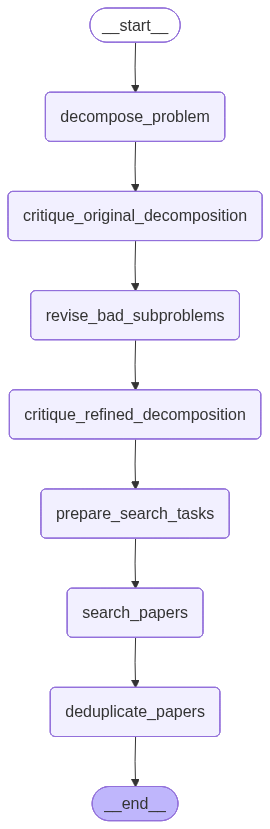

In [80]:
#updating graph
graph_builder = StateGraph(ResearchState)

graph_builder.add_node("decompose_problem", decompose_problem_node)
graph_builder.add_node("critique_original_decomposition", critique_original_decomposition_node)
graph_builder.add_node("revise_bad_subproblems", revise_bad_subproblems_node)
graph_builder.add_node("critique_refined_decomposition", critique_refined_decomposition_node)
graph_builder.add_node("prepare_search_tasks", prepare_search_tasks_node)

graph_builder.add_node("search_papers", search_papers_node_mcp)
graph_builder.add_node("deduplicate_papers", deduplicate_papers_node)

graph_builder.add_edge(START, "decompose_problem")
graph_builder.add_edge("decompose_problem", "critique_original_decomposition")
graph_builder.add_edge("critique_original_decomposition", "revise_bad_subproblems")
graph_builder.add_edge("revise_bad_subproblems", "critique_refined_decomposition")
graph_builder.add_edge("critique_refined_decomposition", "prepare_search_tasks")

graph_builder.add_edge("prepare_search_tasks", "search_papers")
graph_builder.add_edge("search_papers", "deduplicate_papers")
graph_builder.add_edge("deduplicate_papers", END)

graph = graph_builder.compile()
graph

##### agent 4/second critique agent - paper critiquer

In [81]:
""" #this cell is better but on testing it is too heavy for the current model, replacing with lighter for now but later try to run this
class SinglePaperCritique(BaseModel):
    paper_id: str = Field(
        description="ID of the paper being critiqued"
    )

    title: str = Field(
        description="Title of the paper being critiqued"
    )

    is_relevant: bool = Field(
        description="Whether this paper is relevant enough to keep"
    )

    relevance_score: float = Field(
        ge=0.0,
        le=1.0,
        description="How relevant this paper is to the problem statement and subproblem"
    )

    usefulness_score: float = Field(
        ge=0.0,
        le=1.0,
        description="How useful this paper is for implementation planning"
    )

    matched_subproblem_index: int = Field(
        description="Index of the subproblem this paper best matches"
    )

    matched_subproblem_title: str = Field(
        description="Title of the subproblem this paper best matches"
    )

    reason: str = Field(
        description="Why this paper should be kept or discarded"
    )

    limitations: List[str] = Field(
        description="Limitations of using this paper for the project"
    )


class PaperCritiqueReport(BaseModel):
    paper_critiques: List[SinglePaperCritique] = Field(
        description="Critique for each paper"
    )

    kept_paper_ids: List[str] = Field(
        description="Paper IDs that should be kept"
    )

    discarded_paper_ids: List[str] = Field(
        description="Paper IDs that should be discarded"
    )
"""

' #this cell is better but on testing it is too heavy for the current model, replacing with lighter for now but later try to run this\nclass SinglePaperCritique(BaseModel):\n    paper_id: str = Field(\n        description="ID of the paper being critiqued"\n    )\n\n    title: str = Field(\n        description="Title of the paper being critiqued"\n    )\n\n    is_relevant: bool = Field(\n        description="Whether this paper is relevant enough to keep"\n    )\n\n    relevance_score: float = Field(\n        ge=0.0,\n        le=1.0,\n        description="How relevant this paper is to the problem statement and subproblem"\n    )\n\n    usefulness_score: float = Field(\n        ge=0.0,\n        le=1.0,\n        description="How useful this paper is for implementation planning"\n    )\n\n    matched_subproblem_index: int = Field(\n        description="Index of the subproblem this paper best matches"\n    )\n\n    matched_subproblem_title: str = Field(\n        description="Title of the sub

In [82]:
class SinglePaperCritique(BaseModel):
    paper_id: str
    title: str
    is_relevant: bool
    relevance_score: float = Field(ge=0.0, le=1.0)
    usefulness_score: float = Field(ge=0.0, le=1.0)
    reason: str


class PaperCritiqueReport(BaseModel):
    paper_critiques: List[SinglePaperCritique]
    kept_paper_ids: List[str]
    discarded_paper_ids: List[str]

In [83]:
class ResearchState(TypedDict):
    problem_statement: str

    decomposed_problem_statement: Optional[ProblemDecomposition]
    decomposition_critique: Optional[DecompositionCritiqueReport]

    refined_decomposed_problem_statement: Optional[ProblemDecomposition]
    refined_decomposition_critique: Optional[DecompositionCritiqueReport]

    revision_count: int

    search_tasks: Optional[List[SearchTask]]

    raw_papers: Optional[List[PaperResult]]
    deduplicated_papers: Optional[List[PaperResult]]

    paper_critique: Optional[PaperCritiqueReport]
    useful_papers: Optional[List[PaperResult]]

In [84]:
paper_critique_model = model.with_structured_output(PaperCritiqueReport)

paper_critique_prompt = """
You are a strict research paper critique agent.

You will be given:
1. The original problem statement
2. The refined problem decomposition
3. A list of research papers retrieved from ArXiv

Your job:
- Critique each paper individually.
- Decide whether each paper is relevant enough to keep.
- Score each paper for relevance to the problem statement.
- Score each paper for usefulness in implementation planning.
- Match each paper to the most relevant subproblem.
- Discard papers that are too generic, unrelated, purely theoretical without practical value, or not useful for the project.

Scoring guide:
0.90 - 1.00: Very strong paper, highly relevant and useful
0.75 - 0.89: Good paper, keep
0.60 - 0.74: Somewhat useful but not
Below 0.60: Weak or irrelevant, discard

Rules:
- Mark is_relevant=True only if relevance_score >= 0.70.
- Prefer papers that directly help build the system.
- Do not keep papers just because they contain similar keywords.
- Be strict but practical.
"""

In [85]:
#converting papers to json to save space and time
def paper_to_short_dict(paper: PaperResult) -> dict:
    return {
        "paper_id": paper.paper_id,
        "title": paper.title,
        "summary": paper.summary[:700],
        "published": paper.published,
        "url": paper.url,
        "query_used": paper.query_used,
        "subproblem_index_from_search": paper.subproblem_index,
        "subproblem_title_from_search": paper.subproblem_title
    }

In [86]:
def critique_papers(
    problem_statement: str,
    decomposition: ProblemDecomposition,
    papers: List[PaperResult],
    max_papers_to_critique: int = 10
) -> PaperCritiqueReport:

    papers_to_check = papers[:max_papers_to_critique]

    messages = [
        ("system", paper_critique_prompt),
        (
            "user",
            f"""
Original Problem Statement:
{problem_statement}

Refined Problem Decomposition:
{decomposition.model_dump_json(indent=2)}

Retrieved Papers:
{json.dumps([paper_to_short_dict(p) for p in papers_to_check], indent=2)}

Critique each paper and decide which ones should be kept.
"""
        )
    ]

    return paper_critique_model.invoke(messages)

In [87]:
def critique_papers_node(state: ResearchState) -> ResearchState:
    papers = state["deduplicated_papers"]
    decomposition = state["refined_decomposed_problem_statement"]

    if papers is None:
        raise ValueError("No deduplicated_papers found in state")

    if decomposition is None:
        raise ValueError("No refined_decomposed_problem_statement found in state")

    critique = critique_papers(
        problem_statement=state["problem_statement"],
        decomposition=decomposition,
        papers=papers,
        max_papers_to_critique=10
    )

    kept_ids = set(critique.kept_paper_ids)

    useful_papers = [
        paper for paper in papers
        if paper.paper_id in kept_ids
    ]

    return {
        "paper_critique": critique,
        "useful_papers": useful_papers
    }

In [88]:
graph_builder = StateGraph(ResearchState)

graph_builder.add_node("decompose_problem", decompose_problem_node)
graph_builder.add_node("critique_original_decomposition", critique_original_decomposition_node)
graph_builder.add_node("revise_bad_subproblems", revise_bad_subproblems_node)
graph_builder.add_node("critique_refined_decomposition", critique_refined_decomposition_node)

graph_builder.add_node("prepare_search_tasks", prepare_search_tasks_node)
graph_builder.add_node("search_papers", search_papers_node_mcp)
graph_builder.add_node("deduplicate_papers", deduplicate_papers_node)

graph_builder.add_node("critique_papers", critique_papers_node)

graph_builder.add_edge(START, "decompose_problem")
graph_builder.add_edge("decompose_problem", "critique_original_decomposition")
graph_builder.add_edge("critique_original_decomposition", "revise_bad_subproblems")
graph_builder.add_edge("revise_bad_subproblems", "critique_refined_decomposition")

graph_builder.add_edge("critique_refined_decomposition", "prepare_search_tasks")
graph_builder.add_edge("prepare_search_tasks", "search_papers")
graph_builder.add_edge("search_papers", "deduplicate_papers")
graph_builder.add_edge("deduplicate_papers", "critique_papers")
graph_builder.add_edge("critique_papers", END)

graph = graph_builder.compile()

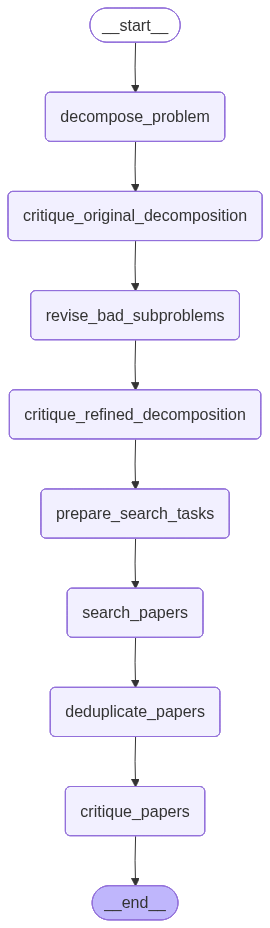

In [78]:
graph

### **later try batch summary for faster and using less tokens**

##### RAG implementation
we will create a rag that will essentially let us condense each paper into its useful chunks and then we will use those for ranking and retrieval later

- Paper search gives candidate papers
- Critique agent filters bad papers
- RAG stores useful paper content as searchable chunks
- RAG retrieves the most relevant chunks for each subproblem
- Final ranking/synthesis uses those chunks as evidence

In [92]:
import sys
!{sys.executable} -m ensurepip --upgrade
!{sys.executable} -m pip install chromadb sentence-transformers

Looking in links: c:\Users\fkrii\AppData\Local\Temp\tmpbhg_aw1_



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
from typing import List, Optional

In [94]:
class RetrievedPaperChunk(BaseModel):
    subproblem_index: int
    subproblem_title: str

    paper_id: str
    paper_title: str
    paper_url: str

    chunk_text: str
    distance: float
    similarity_score: float

In [95]:
class ResearchState(TypedDict):
    problem_statement: str

    decomposed_problem_statement: Optional[ProblemDecomposition]
    decomposition_critique: Optional[DecompositionCritiqueReport]

    refined_decomposed_problem_statement: Optional[ProblemDecomposition]
    refined_decomposition_critique: Optional[DecompositionCritiqueReport]

    revision_count: int

    search_tasks: Optional[List[SearchTask]]

    raw_papers: Optional[List[PaperResult]]
    deduplicated_papers: Optional[List[PaperResult]]

    paper_critique: Optional[PaperCritiqueReport]
    useful_papers: Optional[List[PaperResult]]

    retrieved_paper_chunks: Optional[List[RetrievedPaperChunk]]

In [96]:
embedding_function = SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

chroma_client = chromadb.PersistentClient(
    path="./chroma_research_papers"
)

papers_collection = chroma_client.get_or_create_collection(
    name="papers",
    embedding_function=embedding_function
)

In [97]:
def paper_to_rag_text(paper: PaperResult) -> str:
    return f"""
Title: {paper.title}

Abstract:
{paper.summary}

Published: {paper.published}

Subproblem:
{paper.subproblem_title}

Search query used:
{paper.query_used}

URL:
{paper.url}
""".strip()

In [98]:
def ingest_useful_papers_to_rag(papers: List[PaperResult]) -> int:
    if not papers:
        return 0

    ids = []
    documents = []
    metadatas = []

    for paper in papers:
        paper_id = paper.paper_id.replace("/", "_").replace(".", "_")

        ids.append(paper_id)

        documents.append(
            paper_to_rag_text(paper)
        )

        metadatas.append({
            "paper_id": paper.paper_id,
            "title": paper.title,
            "url": paper.url,
            "published": paper.published,
            "subproblem_index": paper.subproblem_index,
            "subproblem_title": paper.subproblem_title,
            "query_used": paper.query_used,
            "pdf_url": getattr(paper, "pdf_url", "") or "",
            "categories": ", ".join(getattr(paper, "categories", []))
        })

    papers_collection.upsert(
        ids=ids,
        documents=documents,
        metadatas=metadatas
    )

    return len(ids)

In [99]:
def ingest_useful_papers_to_rag_node(state: ResearchState) -> ResearchState:
    useful_papers = state["useful_papers"]

    if useful_papers is None:
        raise ValueError("No useful_papers found in state")

    inserted_count = ingest_useful_papers_to_rag(useful_papers)

    print(f"Ingested {inserted_count} useful papers into RAG")

    return {}

In [100]:
def build_subproblem_retrieval_query(subproblem: SubProblem) -> str:
    return f"""
{subproblem.title}

{subproblem.description}

Research angle:
{subproblem.research_angle}

Keywords:
{", ".join(subproblem.search_keywords)}
""".strip()

In [101]:
def retrieve_chunks_for_subproblem(
    subproblem_index: int,
    subproblem: SubProblem,
    top_k: int = 3
) -> List[RetrievedPaperChunk]:

    query_text = build_subproblem_retrieval_query(subproblem)

    results = papers_collection.query(
        query_texts=[query_text],
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )

    retrieved_chunks = []

    docs = results["documents"][0]
    metas = results["metadatas"][0]
    distances = results["distances"][0]

    for doc, meta, distance in zip(docs, metas, distances):
        similarity_score = 1 / (1 + distance)

        chunk = RetrievedPaperChunk(
            subproblem_index=subproblem_index,
            subproblem_title=subproblem.title,

            paper_id=meta["paper_id"],
            paper_title=meta["title"],
            paper_url=meta["url"],

            chunk_text=doc,
            distance=distance,
            similarity_score=similarity_score
        )

        retrieved_chunks.append(chunk)

    return retrieved_chunks

In [102]:
def retrieve_paper_chunks_from_rag(
    decomposition: ProblemDecomposition,
    top_k_per_subproblem: int = 3
) -> List[RetrievedPaperChunk]:

    all_chunks = []

    for i, subproblem in enumerate(decomposition.subproblems):
        chunks = retrieve_chunks_for_subproblem(
            subproblem_index=i,
            subproblem=subproblem,
            top_k=top_k_per_subproblem
        )

        all_chunks.extend(chunks)

    return all_chunks

In [103]:
def retrieve_paper_chunks_from_rag_node(state: ResearchState) -> ResearchState:
    decomposition = state["refined_decomposed_problem_statement"]

    if decomposition is None:
        raise ValueError("No refined_decomposed_problem_statement found in state")

    retrieved_chunks = retrieve_paper_chunks_from_rag(
        decomposition=decomposition,
        top_k_per_subproblem=3
    )

    return {
        "retrieved_paper_chunks": retrieved_chunks
    }

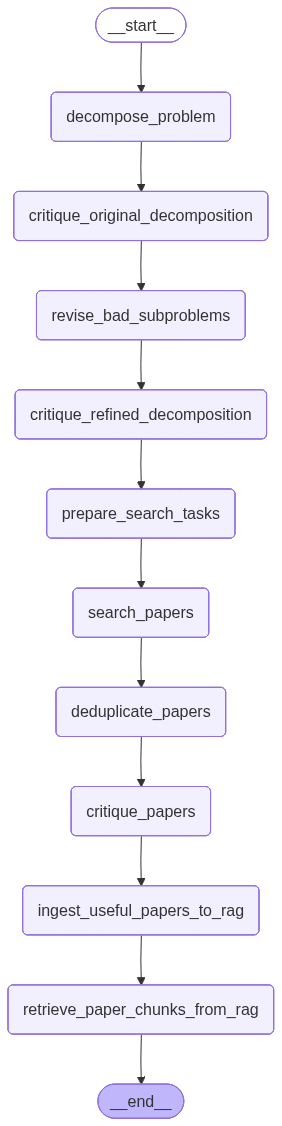

In [104]:
graph_builder = StateGraph(ResearchState)

graph_builder.add_node("decompose_problem", decompose_problem_node)
graph_builder.add_node("critique_original_decomposition", critique_original_decomposition_node)
graph_builder.add_node("revise_bad_subproblems", revise_bad_subproblems_node)
graph_builder.add_node("critique_refined_decomposition", critique_refined_decomposition_node)

graph_builder.add_node("prepare_search_tasks", prepare_search_tasks_node)

# MCP version
graph_builder.add_node("search_papers", search_papers_node_mcp)

graph_builder.add_node("deduplicate_papers", deduplicate_papers_node)
graph_builder.add_node("critique_papers", critique_papers_node)

graph_builder.add_node("ingest_useful_papers_to_rag", ingest_useful_papers_to_rag_node)
graph_builder.add_node("retrieve_paper_chunks_from_rag", retrieve_paper_chunks_from_rag_node)

graph_builder.add_edge(START, "decompose_problem")
graph_builder.add_edge("decompose_problem", "critique_original_decomposition")
graph_builder.add_edge("critique_original_decomposition", "revise_bad_subproblems")
graph_builder.add_edge("revise_bad_subproblems", "critique_refined_decomposition")

graph_builder.add_edge("critique_refined_decomposition", "prepare_search_tasks")
graph_builder.add_edge("prepare_search_tasks", "search_papers")
graph_builder.add_edge("search_papers", "deduplicate_papers")
graph_builder.add_edge("deduplicate_papers", "critique_papers")

graph_builder.add_edge("critique_papers", "ingest_useful_papers_to_rag")
graph_builder.add_edge("ingest_useful_papers_to_rag", "retrieve_paper_chunks_from_rag")
graph_builder.add_edge("retrieve_paper_chunks_from_rag", END)

graph = graph_builder.compile()
graph

testing

In [105]:
result = await graph.ainvoke(initial_state) #since it is async we r using ainvoke instead of invoke

MCP searched query: Automated technical problem decomposition using NLP
Found papers: 3
MCP searched query: Task decomposition for AI system design
Found papers: 3
MCP searched query: Semantic parsing of problem statements into technical components
Found papers: 3
MCP searched query: Semantic search for technical research papers
Found papers: 3
MCP searched query: Domain-specific academic literature retrieval systems
Found papers: 3
MCP searched query: AI-driven paper search for engineering problems
Found papers: 3
MCP searched query: Hybrid ranking algorithms for academic papers
Found papers: 3
MCP searched query: Technical relevance scoring of research documents
Found papers: 3
MCP searched query: Context-aware paper ranking for problem solving
Found papers: 3
MCP searched query: Automated plan generation from research literature
Found papers: 3
MCP searched query: Knowledge integration for technical implementation
Found papers: 3
MCP searched query: Synthesizing academic findings in

In [106]:
print("Raw papers:", len(result["raw_papers"]))
print("Deduplicated papers:", len(result["deduplicated_papers"]))
print("Useful papers:", len(result["useful_papers"]))
print("Retrieved chunks:", len(result["retrieved_paper_chunks"]))

Raw papers: 36
Deduplicated papers: 30
Useful papers: 3
Retrieved chunks: 12
